# Solar Power Generation Forecasting — Model Development

**Author:** Thibaud Wajrock ([GitHub](https://github.com/wajrock) · [LinkedIn](https://linkedin.com/in/wajrock))<br>
**Date:** May 2026

This notebook documents the end-to-end development of a machine learning model
predicting solar power generation for a university campus, using publicly available data from La Trobe University (Australia).

**Summary of results**

| | |
|---|---|
| Final model | LightGBM (Gradient Boosting) |
| Cross-validation | 5-fold `TimeSeriesSplit` |
|R² (all hours) | **0.887** |
| R² (daylight hours) | **0.812** |
| MAE (all hours) | **0.0351** |
| MAE (daylight hours) | **0.0647** |
| Training period | January 2020 – April 2022 |


<a id="0"></a>
## Table of Contents

1. [Context and Objectives](#1)
2. [Data](#2)
3. [Data Preparation](#3)
4. [Data Cleaning](#4)
5. [Feature Engineering](#5)
6. [Exploratory Data Analysis](#6)
7. [Modeling](#7)
8. [Conclusion and Limitations](#8)

<a id="1"></a> 
## 1. Context and Objectives

Year after year, the consequences of climate change are becoming harder to ignore.
In response, energy production is shifting more and more toward renewable sources,
solar power being one of the most widely adopted.

Solar energy produces very little CO2, but it comes with a real limitation: its
generation is much lower and less stable than fossil fuel sources. Generation depends
heavily on weather conditions such as temperature, irradiance, and cloud cover. This
dependency is what makes forecasting valuable: being able to anticipate generation
ahead of time makes it possible to plan around a solar installation's output more
effectively.

The goal of this notebook is to build a model that predicts the solar power
generation of a site from publicly available weather data, in a way that works for a
site of any size, so it can be applied across an entire portfolio of installations
rather than one model per site.


<a id="2"></a> 
## 2. Data

### 2.1 Data Selection

The first step in building our model is selecting a dataset that meets
several criteria:

- **Real, measured production data**
- **Weather data** available for the same timestamps and location as the production
  data
- **Coverage of multiple sites**, to ensure the model generalizes well and to avoid
  overfitting to a single installation
- **A long enough time span** to capture weather variation across seasons

Several options were considered, including local (French) datasets, but none of them
properly linked detailed weather data with real production data.

After reviewing datasets available worldwide, the **[UNISOLAR dataset](https://www.kaggle.com/datasets/cdaclab/unisolar)**
was selected for several reasons: it provides production data at 15-minute
granularity across multiple Australian university campuses, covering sites of
different sizes, over a period of just over two years (**January 2020 to April
2022**).

> This notebook uses the UNISOLAR dataset. Citation: S. Wimalaratne, D. Haputhanthri,
> S. Kahawala, G. Gamage, D. Alahakoon and A. Jennings, "UNISOLAR: An Open Dataset of
> Photovoltaic Solar Energy Generation in a Large Multi-Campus University Setting,"
> 2022 15th International Conference on Human System Interaction (HSI), 2022, pp. 1-5,
> doi: [10.1109/HSI55341.2022.9869474](https://ieeexplore.ieee.org/document/9869474).


### 2.2 Loading and Inventory

The UNISOLAR dataset provides four `.csv` files.

| Original Kaggle file | Renamed to | Content |
|---|---|---|
| `Monthly_Summary_Solar.csv` | `summary.csv` | Monthly aggregated statistics per site (avg, min, max production) |
| `Solar_Site_Details.csv` | `site_details.csv` | Site metadata: installed capacity (kWp), panel/inverter specs, GPS coordinates (42 sites) |
| `Solar_Energy_Generation.csv` | `solar_production.csv` | 15-minute PV energy output per site (kWh) across 5 campuses |
| `Weather_Data_reordered_all.csv` | `weather_unisolar.csv` | 15-minute meteorological data per campus (Australian Bureau of Meteorology) |


In [1]:
import pandas as pd
import numpy as np

df_summary    = pd.read_csv('../assets/summary.csv')
df_sites      = pd.read_csv('../assets/site_details.csv')
df_production = pd.read_csv('../assets/solar_production.csv', parse_dates=['Timestamp'])
df_weather    = pd.read_csv('../assets/weather_unisolar.csv', parse_dates=['Timestamp'])

print(f'summary.csv           : {df_summary.shape}')
print(f'site_details.csv      : {df_sites.shape}')
print(f'solar_production.csv  : {df_production.shape}')
print(f'weather_unisolar.csv  : {df_weather.shape}')

summary.csv           : (1176, 7)
site_details.csv      : (42, 10)
solar_production.csv  : (2731946, 4)
weather_unisolar.csv  : (371769, 8)


`summary.csv` provides monthly aggregated statistics, average, minimum, and maximum
production, per site and year. It offers a useful high-level overview of site
performance, but brings no value to an hourly prediction model, since aggregating
production at the monthly level discards the temporal and meteorological variability
the model needs to learn. It is not used further in this notebook.

### 2.3 Data Quality Assessment

#### 2.3.1 Site Metadata

The `site_details.csv` file provides information for 42 sites across 5 solar campuses in Australia.

In [2]:
display(df_sites.head(3))

,CampusKey,SiteKey,kWp,Number of panels,Panel,Inverter,Optimizers,Metric,lat,Lon
0,2,1,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
2,2,3,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679


The key variable here is `kWp`, which indicates a site's maximum capacity, expressed
in kilowatt-peak (the maximum power a solar installation can produce under standard
test conditions). This value makes it possible to train a single model across sites of
different capacities. Without it, the model would have no way to tell apart a
high-capacity site and a low-capacity site producing under the same weather
conditions, and would end up biased.

In [3]:
print(f"Sites with missing kWp : {df_sites['kWp'].isna().sum()}")

Sites with missing kWp : 17


17 sites out of 42 are unusable due to missing `kWp` values, a significant share of
the dataset. A breakdown by campus shows how these missing values are distributed.

In [4]:
missing_kwp_by_campus = (
    df_sites.groupby('CampusKey')['kWp']
    .apply(lambda x: (x.isna().mean() * 100).round(2))
    .rename('Missing kWp (%)')
    .to_frame().T
)
display(missing_kwp_by_campus.style.format('{:.2f}%').background_gradient(axis=1, cmap='RdYlGn_r'))

CampusKey,1,2,3,4,5
Missing kWp (%),7.41%,100.00%,100.00%,100.00%,100.00%


The per-campus breakdown is clear: campuses 2, 3, 4, and 5 have 100% missing `kWp`
values, making them entirely unusable. Only Campus 1 (Bundoora) has usable capacity
data, with a residual missing rate of about 7%, low enough to be handled by simply
dropping the affected sites, a step carried out later in this document. The rest of this notebook focuses exclusively on Campus 1.

#### 2.3.2 Production Data

`SolarGeneration` is recorded every 15 minutes. The data is filtered to Campus 1,
consistent with section 2.3.1, since it is the only campus with usable `kWp` values.
Missingness is then inspected by hour of day, to check whether it simply reflects
night hours or points to an actual data quality issue.

In [5]:
df_production = df_production[df_production['CampusKey'] == 1]

print(f'Shape : {df_production.shape}')
print(f'Sites : {df_production["SiteKey"].nunique()}')
print(f'Missing rate (SolarGeneration): {df_production["SolarGeneration"].isna().mean() * 100:.2f}%')

missing_by_hour = (
    df_production
    .assign(hour=df_production['Timestamp'].dt.hour)
    .groupby('hour')['SolarGeneration']
    .apply(lambda x: (x.isna().mean() * 100).round(2))
    .rename('Missing (%)')
    .to_frame().T
)
display(missing_by_hour.style.format('{:.2f}%').background_gradient(axis=1, cmap='RdYlGn_r'))

Shape : (1720219, 4)
Sites : 27
Missing rate (SolarGeneration): 55.87%


hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Missing (%),99.95%,99.93%,99.96%,99.96%,99.96%,99.96%,90.49%,48.85%,12.04%,6.24%,5.58%,6.45%,11.27%,14.64%,11.69%,6.27%,6.29%,25.92%,47.14%,58.84%,88.67%,99.95%,99.96%,99.96%


A per-hour breakdown reveals three distinct regimes. True night hours (21:00 to
05:00) are missing in over 99% of cases, which could be explained by the absence of
solar irradiance at those hours. Core daylight hours (08:00 to 16:00) show a low
missing rate (under 15%), which could point to occasional logging gaps rather than a
systematic issue. The hours surrounding sunrise and sunset (06:00 to 07:00, 17:00 to
20:00) show a markedly higher missing rate (26% to 90%), too high to be explained by
isolated logging gaps, but not high enough to be pure night either. These transition
hours are examined further in section 3.4.


#### 2.3.3 Weather Data

The same approach applied to production data is used here: the weather data is
examined for missing values, and their distribution is analyzed by hour of day, to
determine whether a similar day/night pattern is present.

In [6]:
df_weather = df_weather[df_weather['CampusKey'] == 1]

print(f'Shape  : {df_weather.shape}')
print(f'Period : {df_weather["Timestamp"].min()} to {df_weather["Timestamp"].max()}')

missing_weather = (df_weather.isna().mean() * 100).round(2).rename('Missing (%)').to_frame().T

print('\nMissing data rate by variable')
display(missing_weather.style.format('{:.2f}%'))

missing_by_hour_weather = (
    df_weather
    .assign(hour=df_weather['Timestamp'].dt.hour)
    .groupby('hour')[['ApparentTemperature', 'AirTemperature', 'DewPointTemperature',
                       'RelativeHumidity', 'WindSpeed', 'WindDirection']]
    .apply(lambda x: (x.isna().mean() * 100).round(2))
    .T
)

print('\nMissing data rate by variable and by hour')
display(missing_by_hour_weather.style.format('{:.2f}%').background_gradient(axis=1, cmap='RdYlGn_r'))

Shape  : (81017, 8)
Period : 2020-01-01 00:00:00 to 2022-04-23 22:00:00

Missing data rate by variable


,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
Missing (%),0.00%,0.00%,18.26%,18.26%,18.26%,18.26%,36.65%,36.65%



Missing data rate by variable and by hour


hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
ApparentTemperature,18.25%,18.34%,18.42%,18.39%,18.28%,18.34%,18.25%,18.25%,18.28%,18.31%,18.25%,18.19%,18.13%,18.16%,17.92%,18.25%,18.25%,18.28%,18.31%,18.36%,18.31%,18.22%,18.26%,18.33%
AirTemperature,18.25%,18.34%,18.42%,18.39%,18.28%,18.34%,18.25%,18.25%,18.28%,18.31%,18.25%,18.19%,18.13%,18.16%,17.92%,18.25%,18.25%,18.28%,18.31%,18.36%,18.31%,18.22%,18.26%,18.33%
DewPointTemperature,18.25%,18.34%,18.42%,18.39%,18.28%,18.34%,18.25%,18.25%,18.28%,18.31%,18.25%,18.19%,18.13%,18.16%,17.92%,18.25%,18.25%,18.28%,18.31%,18.36%,18.31%,18.22%,18.26%,18.33%
RelativeHumidity,18.25%,18.34%,18.42%,18.39%,18.28%,18.34%,18.25%,18.25%,18.28%,18.31%,18.25%,18.19%,18.13%,18.16%,17.92%,18.25%,18.25%,18.28%,18.31%,18.36%,18.31%,18.22%,18.26%,18.33%
WindSpeed,36.49%,36.49%,36.64%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.67%,36.65%
WindDirection,36.49%,36.49%,36.64%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.61%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.73%,36.67%,36.65%


Looking at the missing data, this time the missing values are spread fairly evenly
across the day, with a missing rate of about 18% in the best case, rising to around
37% for wind-related variables. This level of missing data is a real problem for
building a weather-based prediction model. With that much missing data, the model
would struggle to capture the day-to-day variation and account for the weather
conditions that actually affect a solar panel's output. The next section discusses
replacing this weather data.

<a id="3"></a> 
## 3. Data Preparation

### 3.1 Weather Source Replacement

Replacing the weather data included in the UNISOLAR dataset requires a source
providing complete weather data, on the same time scale as the production data, and
for the exact location of Campus 1.

The **Open-Meteo Historical API** meets this requirement: hourly meteorological
records were fetched for the GPS coordinates of the Bundoora campus, covering the same
period as the production data.

Open-Meteo's Forecast API also exposes the same variables as its Historical API. This
has an implication beyond model training: it enables prediction of future solar
production, by supplying the model with weather forecasts from this same API instead
of historical records.

Two changes were made relative to the original UNISOLAR weather data, described below.

- **`temperature`** (ambient air temperature) is used instead of *apparent*
  temperature. Panel output is driven by ambient temperature, not the "feels-like"
  temperature used for human comfort. The two variables are highly correlated, making
  this a like-for-like, more physically appropriate replacement.
- The Open-Meteo API exposes a substantially larger set of weather variables than the
  original UNISOLAR weather data, which could improve model performance through a
  richer feature space. An initial, theory-driven selection of variables plausibly
  related to solar production is used at this stage; a more rigorous selection, based
  on empirical correlation with the target, is carried out later in this notebook.

The Open-Meteo Historical API was queried once for the full production period, and the
result was cached to `weather_open_meteo.csv`.


In [7]:
df_weather = pd.read_csv('../assets/weather_open_meteo.csv', parse_dates=['timestamp'])

print(f'Shape : {df_weather.shape}')
print(f'Missing values : {df_weather.isna().sum().sum()}')
display(df_weather.describe())

Shape : (20088, 10)
Missing values : 0


,timestamp,temperature,relative_humidity,dew_point,wind_speed,wind_direction,cloud_cover,shortwave_radiation,direct_radiation,diffuse_radiation
count,20088,20088.000000,20088.000000,20088.000000,20088.000000,20088.000000,20088.000000,20088.000000,20088.000000,20088.000000
mean,2021-03-01 11:30:00.000000256,14.572192,74.140382,9.498093,11.913326,189.863003,60.973666,174.648397,110.097919,64.550478
min,2020-01-08 00:00:00,-0.400000,15.000000,-1.100000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2020-08-04 05:45:00,10.400000,62.000000,6.700000,6.800000,108.000000,22.000000,0.000000,0.000000,0.000000
50%,2021-03-01 11:30:00,13.800000,76.000000,9.100000,11.100000,199.000000,73.000000,8.000000,0.000000,6.000000
75%,2021-09-26 17:15:00,17.900000,88.000000,12.100000,16.200000,274.000000,99.000000,298.000000,136.000000,106.000000
max,2022-04-23 23:00:00,40.800000,100.000000,22.400000,49.300000,360.000000,100.000000,1081.000000,969.000000,475.000000
std,NaN,5.782931,16.839279,3.850738,6.463190,108.929032,38.735010,254.626016,197.039067,90.920107


### 3.2 Site Filtering

Section 2.3.1 established that Campus 1 retains a residual share of sites with
missing `kWp` values. As `kWp` is required for the model, these sites cannot
contribute to training and are removed: `df_sites` is restricted to Campus 1, and the
sites still missing `kWp` are dropped. The production data is subsequently restricted
to this same set of usable sites.

In [8]:
df_sites = df_sites[df_sites['CampusKey'] == 1]
df_sites = df_sites.dropna(subset=['kWp'])

print(f'Number of sites retained (Campus 1, with known kWp): {len(df_sites)}')

df_production = df_production[df_production['SiteKey'].isin(df_sites['SiteKey'])]

Number of sites retained (Campus 1, with known kWp): 25


### 3.3 Hourly Aggregation of Production

To ensure the model's relevance, the production data needs to be aligned on the same
time scale as the weather data. `SolarGeneration` is an energy measurement (kWh)
recorded every 15 minutes. To match the hourly resolution of the weather data,
production is aggregated to hourly frequency.

Energy is additive over time, so the total energy produced in an hour is the sum of
its four 15-minute readings. An hour is only retained as a complete measurement if all
four underlying readings are present, otherwise it is flagged as missing, to avoid
silently underestimating production from a partial sum.

In [9]:
df_production['timestamp'] = df_production['Timestamp'].dt.ceil('1h')

df_production_hourly = (
    df_production
    .groupby(['SiteKey', 'timestamp'])
    .agg(solar_generation=('SolarGeneration', 'sum'),
         readings_count=('SolarGeneration', 'count'))
    .reset_index()
)

df_production_hourly.loc[df_production_hourly['readings_count'] != 4, 'solar_generation'] = np.nan
df_production_hourly = df_production_hourly.drop(columns=['readings_count'])

print(f"Missing rate after aggregation: {df_production_hourly['solar_generation'].isna().mean() * 100:.2f}%")

Missing rate after aggregation: 60.76%


A missing rate of 60.76% is obtained, which is clearly problematic, since
`solar_generation` is one of the key variables for this model. A breakdown by hour of
day helps interpret this rate more precisely.

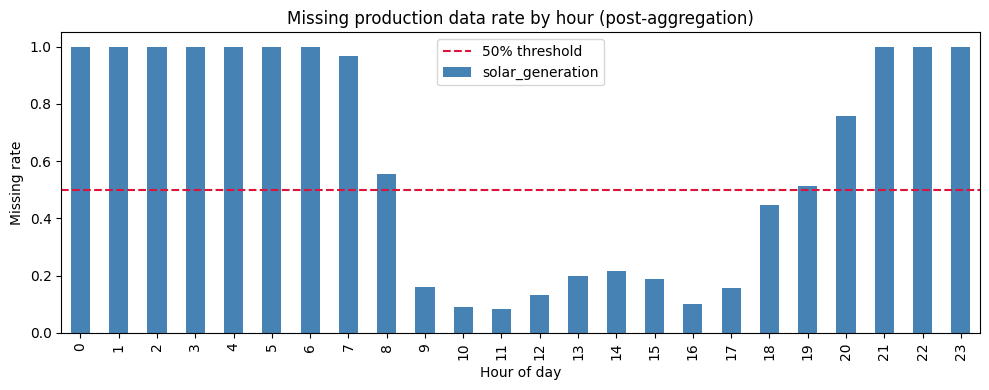

In [10]:
import matplotlib.pyplot as plt

missing_by_hour = (
    df_production_hourly
    .groupby(df_production_hourly['timestamp'].dt.hour)['solar_generation']
    .apply(lambda s: s.isna().mean())
)

fig, ax = plt.subplots(figsize=(10, 4))
missing_by_hour.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0.5, color='crimson', linestyle='--', label='50% threshold')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Missing rate')
ax.set_title('Missing production data rate by hour (post-aggregation)')
ax.legend()
plt.tight_layout()
plt.show()

The missing rate is not uniform. Hours 21:00 to 07:00 are missing 97% to 100% of the
time, which could be explained by the total absence of solar irradiance. Core daylight
hours (09:00 to 17:00) show a low, stable missing rate (9% to 22%), which could point
to occasional logging gaps rather than a systemic problem.

The remaining hours, 08:00, 18:00, 19:00, and 20:00, are more difficult to interpret.
These hours cannot be labeled "night" or "day" on a fixed basis, since actual daylight
status shifts with the seasons. On the Bundoora campus (Australia), at 08:00 for
instance, the sun is well up in December but not yet risen in June. Treating these
hours as a single fixed category would either erase real summer production or leave
genuine winter darkness unaccounted for.


### 3.4 Missing Data Imputation

The previous section flagged a few transition hours (08:00, 18:00, 19:00, 20:00) that
could not be clearly labeled "night" or "day" on their own. Since daylight hours shift
with the seasons, the chart below checks whether these transition hours behave
differently across seasons.

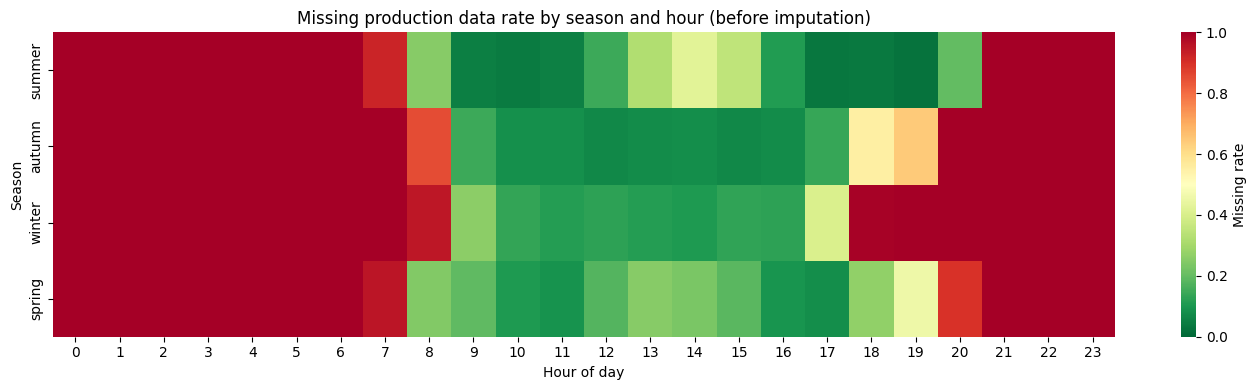

In [11]:
import seaborn as sns

season_map = {12: 'summer', 1: 'summer', 2: 'summer',
              3: 'autumn',  4: 'autumn',  5: 'autumn',
              6: 'winter',  7: 'winter',  8: 'winter',
              9: 'spring', 10: 'spring', 11: 'spring'}

missing_by_season_hour_before = (
    df_production_hourly
    .assign(season=df_production_hourly['timestamp'].dt.month.map(season_map),
            hour=df_production_hourly['timestamp'].dt.hour)
    .groupby(['season', 'hour'])['solar_generation']
    .apply(lambda s: s.isna().mean())
    .unstack('hour')
    .reindex(['summer', 'autumn', 'winter', 'spring'])
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(missing_by_season_hour_before, cmap='RdYlGn_r', vmin=0, vmax=1,
            cbar_kws={'label': 'Missing rate'}, ax=ax)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Season')
ax.set_title('Missing production data rate by season and hour (before imputation)')
plt.tight_layout()
plt.show()

The clear night hours (0 to 6, 21 to 23) show a missing rate near 100% in every
season, and the clear day hours (9 to 16) show a low rate in every season, matching
what section 3.3 already found.

The transition hours are where seasons diverge. Winter goes dark earliest (18:00 is
already close to 100% missing, versus 5% to 15% for summer at the same hour), and
autumn lags behind in the morning (hour 8 is still close to 80% missing, while summer
and winter have already dropped to a low rate). Since sunrise and sunset shift by a
few hours between seasons, these transition hours cannot use one fixed day/night rule
for the whole year. Instead, the gaps are filled hour by hour within each season:

1. For every (season, hour) pair, check how often data is missing.
2. If it is missing 90% of the time or more, treat that pair as night and fill the
   gaps with 0, since there was no sunlight and 0 is the correct value.
3. Otherwise, treat it as day. Day gaps are never filled with 0, since real
   production could have happened. Only short gaps (up to 2 hours) are filled, by
   taking a value in between the readings just before and after. Longer day gaps are
   left as missing rather than guessed.


Missing production data rate after imputation: 11.84%


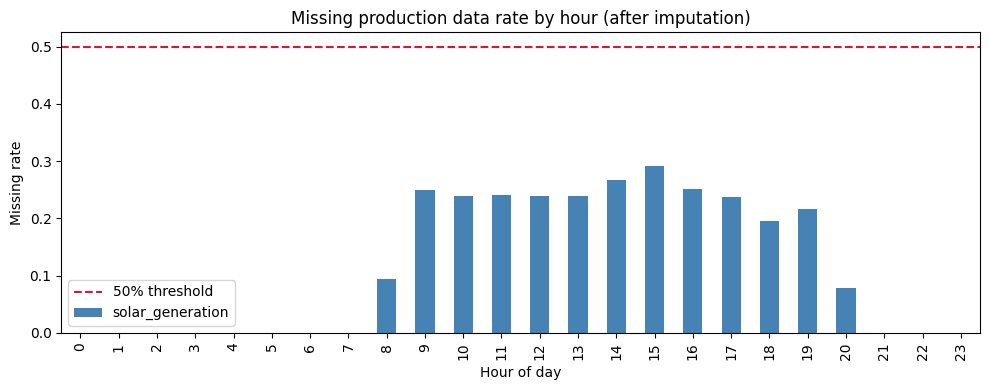

In [12]:
full_range = pd.date_range(df_production_hourly['timestamp'].min(),
                            df_production_hourly['timestamp'].max(), freq='1h')
full_index = pd.MultiIndex.from_product(
    [df_production_hourly['SiteKey'].unique(), full_range], names=['SiteKey', 'timestamp']
)
df_production_hourly = (
    df_production_hourly.set_index(['SiteKey', 'timestamp']).reindex(full_index).reset_index()
)

df_production_hourly['season'] = df_production_hourly['timestamp'].dt.month.map(season_map)
df_production_hourly['hour']   = df_production_hourly['timestamp'].dt.hour

missing_by_season_hour = (
    df_production_hourly.groupby(['season', 'hour'])['solar_generation']
    .apply(lambda s: s.isna().mean())
    .rename('missing_rate').reset_index()
)
df_production_hourly = df_production_hourly.merge(missing_by_season_hour, on=['season', 'hour'], how='left')

is_night = df_production_hourly['missing_rate'] >= 0.90
df_production_hourly.loc[is_night, 'solar_generation'] = (
    df_production_hourly.loc[is_night, 'solar_generation'].fillna(0)
)

df_production_hourly = df_production_hourly.sort_values(['SiteKey', 'timestamp'])
mask_day = ~is_night
df_production_hourly.loc[mask_day, 'solar_generation'] = (
    df_production_hourly[mask_day]
    .groupby('SiteKey')['solar_generation']
    .transform(lambda x: x.interpolate(method='linear', limit=2))
)

df_production_hourly = df_production_hourly.drop(columns=['season', 'hour', 'missing_rate'])

missing_by_hour_after = (
    df_production_hourly
    .groupby(df_production_hourly['timestamp'].dt.hour)['solar_generation']
    .apply(lambda s: s.isna().mean())
)

print(f"Missing production data rate after imputation: {df_production_hourly['solar_generation'].isna().mean() * 100:.2f}%")

fig, ax = plt.subplots(figsize=(10, 4))
missing_by_hour_after.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(0.5, color='crimson', linestyle='--', label='50% threshold')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Missing rate')
ax.set_title('Missing production data rate by hour (after imputation)')
ax.legend()
plt.tight_layout()
plt.show()

The overall missing rate drops from about 60.76% (section 3.3, before imputation) to
11.84%. Comparing the two hourly charts, night hours now show 0% missing, confirming
the fill-with-zero step worked as intended. The residual 11.84% is entirely made up of
daytime gaps too long to interpolate reliably, left as missing rather than filled with
an assumed value.

In [13]:
missing_by_site = (
    df_production_hourly
    .groupby('SiteKey')['solar_generation']
    .apply(lambda s: s.isna().mean())
    .sort_values(ascending=False)
)

display(
    missing_by_site
    .mul(100).round(1)
    .rename('Missing (%)')
    .to_frame().T
    .style.format('{:.1f}%')
)

SiteKey,16,30,39,23,14,25,18,19,26,21,20,32,17,36,40,37,22,24,33,38,31,15,35,34,27
Missing (%),21.0%,14.3%,14.2%,14.2%,12.5%,12.4%,12.3%,12.2%,11.8%,11.7%,11.5%,11.5%,11.4%,11.4%,11.4%,11.4%,11.4%,11.3%,11.3%,11.3%,11.3%,11.0%,9.6%,7.7%,6.0%


The per-site breakdown shows this residual rate is fairly consistent across most
sites, roughly 6% to 14%. Site 16 stands out at 21%, noticeably above the rest. This
site, along with other potentially problematic sites, is investigated further later in
this document.

### 3.5 Merge

Production and weather data can now be merged on `timestamp`. Only hours present in
both datasets are kept (`inner` join).

In [14]:
df_final = (
    df_production_hourly
    .merge(df_weather, on='timestamp', how='inner')
    .merge(df_sites[['SiteKey', 'kWp']], on='SiteKey', how='inner')
    .rename(columns={'SiteKey': 'site_key', 'kWp': 'kwp'})
)

print(f'Records : {len(df_final):,}')
print(f'Sites   : {df_final["site_key"].nunique()}')
print(f'Period  : {df_final["timestamp"].min()} to {df_final["timestamp"].max()}')

display(
    (df_final.isna().mean() * 100).round(2).rename('Missing (%)').to_frame().T
    .style.format('{:.2f}%').background_gradient(axis=1, cmap='RdYlGn_r')
)

Records : 502,200
Sites   : 25
Period  : 2020-01-08 00:00:00 to 2022-04-23 23:00:00


,site_key,timestamp,solar_generation,temperature,relative_humidity,dew_point,wind_speed,wind_direction,cloud_cover,shortwave_radiation,direct_radiation,diffuse_radiation,kwp
Missing (%),0.00%,0.00%,11.49%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


The merged dataset spans 2020-01-08 to 2022-04-23, across 25 sites with usable `kWp`
data. Every column is complete except `solar_generation`, which now retains a residual
missing rate of 11.49%. This residual rate is reduced further later in this
document, to train the model on the most reliable data available.

The dataset is now ready for target computation and feature engineering.

<a id="4"></a> 
## 4. Data Cleaning

### 4.1 Target Definition

The model target is `capacity_factor = solar_generation / kwp`, the ratio of actual
output to installed peak capacity. Normalizing by capacity is what allows a single
model to generalize across sites of substantially different sizes.

Capacity factor also serves as a useful diagnostic. Being bounded and comparable
across sites, it can be checked against a documented expected range. According to
[SurgePV](https://www.surgepv.com/glossary/capacity-factor), fixed-tilt residential
solar typically reaches 15% to 20%, and commercial flat-roof systems 14% to 18%. A raw
kWh reading carries no such built-in expectation, since a small site may legitimately
produce far less than a large one, making an unusual reading difficult to identify on
its own. A site falling far outside the expected range, in either direction, is more
likely to indicate a data quality issue than a genuine difference in performance.

In [15]:
df_final['capacity_factor'] = df_final['solar_generation'] / df_final['kwp']
display(df_final['capacity_factor'].describe())

count    444496.000000
mean          0.149321
std           0.345260
min           0.000000
25%           0.000000
50%           0.000000
75%           0.186505
max           4.899658
Name: capacity_factor, dtype: float64

With 444,496 records, the average capacity factor is 14.9%, squarely within the
expected range. The median and 25th percentile are both 0, meaning
at least a quarter of the records are exactly zero. This is expected, since capacity
factor is 0 every night, and night hours make up a large share of an hourly dataset.
The 75th percentile (18.7%) reflects daytime values, and sits comfortably within the
expected range.

The maximum, however, is 4.90. A capacity factor above 1.0 is physically impossible,
since a site cannot produce more energy than its installed capacity. This confirms at
least one site has a data issue. Because this single distribution mixes all sites
together, it cannot reveal which one is responsible. The next step breaks capacity
factor down by site and year to isolate the anomaly.

### 4.2 Site-Level Anomaly Detection


In [16]:
cf_by_site_year = (
    df_final.groupby(['site_key', df_final['timestamp'].dt.year])['capacity_factor']
    .mean().unstack()
)
cf_by_site_year.columns.name = 'Year'
display(cf_by_site_year.style.format('{:.1%}').background_gradient(cmap='RdYlGn_r'))

Year,2020,2021,2022
site_key,,,
14,9.6%,13.9%,17.4%
15,9.3%,13.4%,16.9%
16,1.1%,7.5%,9.2%
17,9.4%,13.6%,16.7%
18,9.5%,14.2%,17.6%
19,55.3%,81.7%,101.3%
20,9.8%,14.0%,17.4%
21,9.0%,13.2%,16.6%
22,9.1%,13.2%,16.3%


Nearly every site shows a rising capacity factor from 2020 to 2022. This does not
reflect a real improvement in performance: 2022 only covers January through April,
and since that range includes the peak summer months of January and February, the
partial-year average for 2022 is skewed upward compared to a full calendar year.

Four sites do not follow this pattern and are excluded:

- Site 19 reaches an impossible 101.3% by 2022, showing a `kWp` data error.

- Site 24 stays above the expected range every year and, unlike the other sites,
  falls instead of rising in 2022, suggesting a separate data issue.

- Sites 16 and 39 stay well below the expected range across all three years. In the
  inflated 2022 figures, site 16 reaches barely half the value of comparable sites,
  and site 39 remains well below as well, though less severely.

The remaining 21 sites follow the expected pattern and stay within a consistent,
plausible range once the year-on-year trend is taken into account.

In [17]:
sites_to_exclude = [16, 19, 24, 39]
df_final = df_final[~df_final['site_key'].isin(sites_to_exclude)].reset_index(drop=True)

print(f'Sites remaining : {df_final["site_key"].nunique()}')
print(f'Dataset shape   : {df_final.shape}')

total_kwp = df_final.drop_duplicates('site_key')['kwp'].sum()
print(f'Combined installed capacity : {total_kwp:,.0f} kWp')

Sites remaining : 21
Dataset shape   : (421848, 14)
Combined installed capacity : 2,119 kWp


The 21 retained sites total approximately 2,119 kWp of combined installed capacity.
This is the figure used throughout the rest of the project when referring to overall
campus capacity.

<a id="5"></a> 
## 5. Feature Engineering

To ensure the model's relevance, the data must be processed to preserve physical
consistency and to strengthen the correlation between features and the target
variable.

### 5.1 Cyclic Encoding

Hour and month are periodic: hour 23 is closer to hour 0 than to hour 12, and
December is closer to January than to June. A naive integer encoding would not
capture this continuity, and would mislead a model into treating, for
instance, hour 0 and hour 23 as maximally different. Sin/cos encoding maps each value
onto a unit circle, preserving the cyclic structure.

In [18]:
df_final['hour']  = df_final['timestamp'].dt.hour
df_final['month'] = df_final['timestamp'].dt.month

df_final['hour_sin']  = np.sin(2 * np.pi * df_final['hour']  / 24)
df_final['hour_cos']  = np.cos(2 * np.pi * df_final['hour']  / 24)
df_final['month_sin'] = np.sin(2 * np.pi * df_final['month'] / 12)
df_final['month_cos'] = np.cos(2 * np.pi * df_final['month'] / 12)


df_final = df_final.drop(columns=['hour', 'month'])


### 5.2 Weather Feature Selection

Rather than retaining every variable fetched from Open-Meteo by default, correlation
analysis is used to identify redundant features and those most associated with the
target. The analysis is restricted to hours with non-zero solar radiation, since this
is when weather conditions actually influence production.

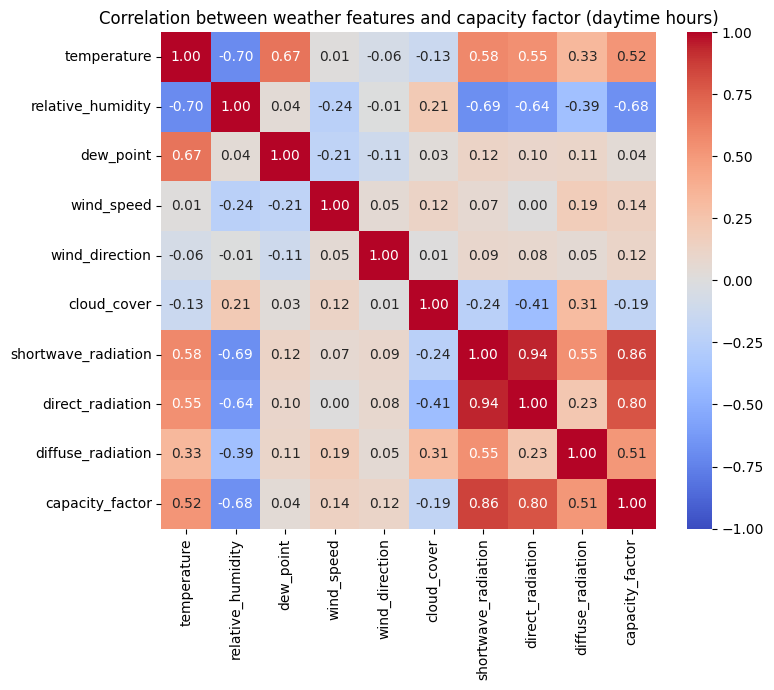

In [19]:
day_mask = df_final['shortwave_radiation'] > 0

weather_vars = ['temperature', 'relative_humidity', 'dew_point', 'wind_speed', 'wind_direction',
                'cloud_cover', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
                'capacity_factor']

corr_matrix = df_final.loc[day_mask, weather_vars].corr()

plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between weather features and capacity factor (daytime hours)')
plt.tight_layout()
plt.show()

The correlation matrix guides which weather variables to keep, based on two things:
how strongly a variable correlates with the target, and how strongly it correlates
with other variables already kept, which indicates redundancy.

| Variable | Correlation with target | Decision | Reason |
|---|---|---|---|
| `shortwave_radiation` | 0.86 | Kept | Strongest correlation with the target among the three irradiance variables |
| `direct_radiation` | 0.80 | Dropped | Correlates at 0.94 with `shortwave_radiation`, a near duplicate with a weaker link to the target |
| `diffuse_radiation` | 0.51 | Kept | Correlates only 0.23 with `direct_radiation`, so it is not redundant |
| `cloud_cover` | -0.19 | Kept | Correlates only weakly with the other kept features |
| `dew_point` | 0.04 | Dropped | Correlates at 0.67 with `temperature`, and is barely linked to the target |
| `temperature` | 0.52 | Kept | Correlates with `shortwave_radiation` (0.58), but not strongly enough to be redundant |
| `relative_humidity` | -0.68 | Kept | Correlates with `shortwave_radiation` (-0.69), but by the same reasoning is not redundant |
| `wind_speed` | 0.14 | Dropped | Correlation with the target is too weak to justify keeping it |
| `wind_direction` | 0.12 | Dropped | Correlation with the target is too weak to justify keeping it |

In [20]:
df_final = df_final.drop(columns=['direct_radiation', 'dew_point', 'wind_speed', 'wind_direction'])
display(df_final.head(3))

,site_key,timestamp,solar_generation,temperature,relative_humidity,cloud_cover,shortwave_radiation,diffuse_radiation,kwp,capacity_factor,hour_sin,hour_cos,month_sin,month_cos
0,14,2020-01-08 00:00:00,0.0,15.8,95,96,0.0,0.0,66.0,0.0,0.000000,1.000000,0.5,0.866025
1,14,2020-01-08 01:00:00,0.0,15.8,95,100,0.0,0.0,66.0,0.0,0.258819,0.965926,0.5,0.866025
2,14,2020-01-08 02:00:00,0.0,15.8,94,100,0.0,0.0,66.0,0.0,0.500000,0.866025,0.5,0.866025


### 5.3 Final Feature Set

At this point, the dataframe contains 14 columns. `solar_generation` is excluded, as the target (`capacity_factor`) is derived directly from
it, and using it as an input would leak the answer. `timestamp` is excluded as well,
its relevant information (hour, month) is already captured by the cyclic encodings
introduced in section 5.1. `site_key` is excluded as a raw identifier carrying no
information a model could learn from; `kwp` is used in its place, as it is the
measurable site property that actually explains differences in production, and
generalizes to sites not seen during training.

The remaining columns, selected through the weather feature analysis (section 5.2)
and the time encodings (section 5.1), make up the final feature set:

| Feature | Description |
|---|---|
| `temperature` | Air temperature (°C) |
| `relative_humidity` | Relative humidity (%) |
| `cloud_cover` | Cloud cover (%) |
| `shortwave_radiation` | Solar irradiance (W/m²) |
| `diffuse_radiation` | Diffuse component of irradiance (W/m²) |
| `hour_sin`, `hour_cos` | Cyclic encoding of hour of day |
| `month_sin`, `month_cos` | Cyclic encoding of month |
| `kwp` | Installed peak capacity |

Target: `capacity_factor = solar_generation / kwp`

In [21]:
FEATURES = [
    'temperature', 'relative_humidity', 'cloud_cover',
    'shortwave_radiation', 'diffuse_radiation',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'kwp',
]
TARGET = 'capacity_factor'

print('Features :', FEATURES)
print('Target   :', TARGET)
print(f'Shape    : {df_final[FEATURES + [TARGET]].shape}')

Features : ['temperature', 'relative_humidity', 'cloud_cover', 'shortwave_radiation', 'diffuse_radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'kwp']
Target   : capacity_factor
Shape    : (421848, 11)


<a id="6"></a> 
## 6. Exploratory Data Analysis

Before modeling, a few visual checks help build intuition about the target variable
and confirm the patterns the model will need to learn.

### 6.1 Average Daily Production Profile

Averaging capacity factor by hour of day, across the full period, should trace out the
expected solar bell curve: rising after sunrise, peaking around solar noon, and
falling back to zero after sunset. This also serves as a sanity check on the cyclic
encoding introduced in section 5.1, since the model can only be expected to perform
well if this pattern is present in the data and learnable from `hour_sin` and
`hour_cos`.

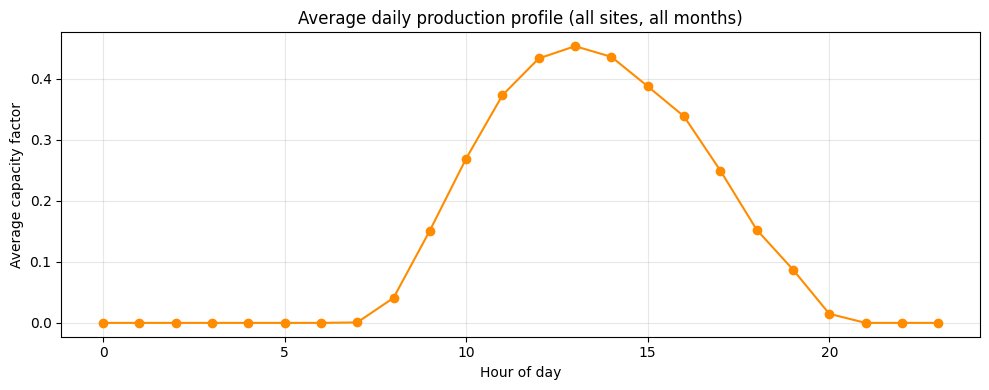

In [22]:
hourly_profile = (
    df_final.assign(hour=df_final['timestamp'].dt.hour)
    .groupby('hour')[TARGET].mean()
)

fig, ax = plt.subplots(figsize=(10, 4))
hourly_profile.plot(ax=ax, marker='o', color='darkorange')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Average capacity factor')
ax.set_title('Average daily production profile (all sites, all months)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The curve follows the expected solar pattern. Capacity factor is at 0 from hour 20
through hour 7, consistent with nighttime. It then rises sharply from hour 8, reaches
a peak of about 0.45 between hours 12 and 13, close to solar noon, and declines
symmetrically back to 0 by hour 20. This confirms that `hour_sin` and `hour_cos`
capture a real, learnable pattern in the data.

The peak value of 0.45 does not contradict the 15% to 20% average capacity factor
range cited in section 4.1: that range describes an average over an entire day,
including the many hours with little or no output, while the value shown here is the
average for a single peak hour only, when production is at its highest.

### 6.2 Seasonal Pattern

Solar irradiance in southeastern Australia varies substantially between summer and
winter. A monthly view of capacity factor should reflect this, with higher output
around the Southern Hemisphere summer (December to February) and lower output around
winter (June to August). This is the seasonal signal that `month_sin` and `month_cos`
are meant to expose to the model.

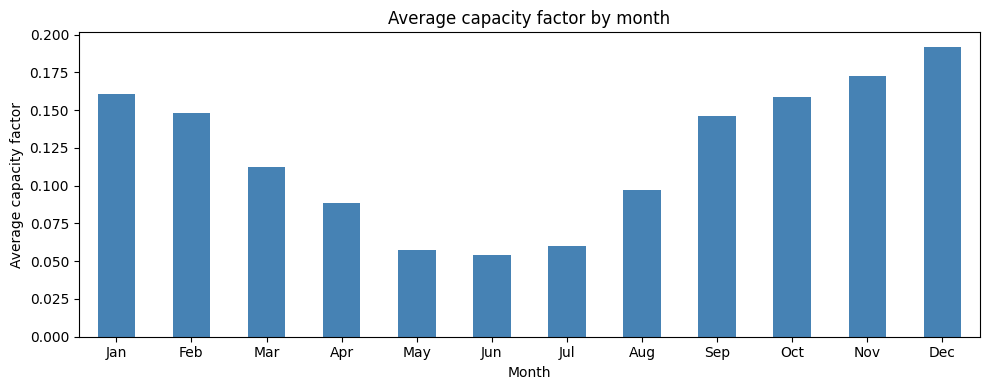

In [23]:
monthly_cf = (
    df_final.assign(month=df_final['timestamp'].dt.month)
    .groupby('month')[TARGET].mean()
)

fig, ax = plt.subplots(figsize=(10, 4))
monthly_cf.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Month')
ax.set_ylabel('Average capacity factor')
ax.set_title('Average capacity factor by month')
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()

The chart confirms the expected seasonal pattern. The lowest values occur in the
winter months (May to July), and the highest values occur in the summer months
(November to January), consistent with the Southern Hemisphere seasons described
above. The transition months (autumn: March to April, spring: September to October)
fall between these two extremes, forming a smooth curve rather than an abrupt shift,
which is consistent with a gradual seasonal transition in irradiance.

<a id="7"></a> 
## 7. Modeling

### 7.1 Final Data Cleaning

Previous sections left some daytime gaps in `solar_generation` unfilled by design,
rather than guessing their value. These remaining missing values are dropped now,
since a model cannot be trained on records without a target.

In [24]:
df_clean = df_final.dropna(subset=[TARGET]).sort_values('timestamp').reset_index(drop=True)

print(f'Rows before cleaning : {len(df_final):,}')
print(f'Rows after cleaning  : {len(df_clean):,}')
print(f'Rows dropped         : {len(df_final) - len(df_clean):,}')

Rows before cleaning : 421,848
Rows after cleaning  : 375,691
Rows dropped         : 46,157


### 7.2 Train / Test Split

The dataset is split chronologically, using the first 80% of records for training and
the last 20% for testing. A random split would leak future information into training,
which does not reflect real-world forecasting conditions, where only the past is
available at prediction time.

In [25]:
unique_dates = df_clean['timestamp'].unique()
cutoff_date = unique_dates[int(len(unique_dates) * 0.8)]

df_train = df_clean[df_clean['timestamp'] < cutoff_date].reset_index(drop=True)
df_test  = df_clean[df_clean['timestamp'] >= cutoff_date].reset_index(drop=True)

X_train, y_train = df_train[FEATURES].values, df_train[TARGET].values
X_test,  y_test  = df_test[FEATURES].values,  df_test[TARGET].values

print(f'Train : {len(df_train):,} rows ({df_train["timestamp"].min().date()} to {df_train["timestamp"].max().date()})')
print(f'Test  : {len(df_test):,} rows ({df_test["timestamp"].min().date()} to {df_test["timestamp"].max().date()})')

Train : 293,248 rows (2020-01-08 to 2021-11-08)
Test  : 82,443 rows (2021-11-08 to 2022-04-23)


### 7.3 Baseline Models

Before considering more complex machine learning models, the dataset is evaluated
against simple baselines. This tests the initial hypothesis and establishes whether a
machine learning model is genuinely useful for this problem, rather than assuming it
from the start.

- Naive seasonal average: predicts the historical mean `capacity_factor` for the
  matching (hour, month) combination, learned from the training set. This captures
  the day/night and seasonal cycle by construction, without using any weather
  information, providing a useful floor to beat.
- Linear Regression: the simplest model that does use the weather features,
  establishing whether a linear combination of predictors is sufficient, or whether
  the relationship between weather and production is meaningfully non-linear.

A shared `evaluate()` helper reports overall R² and MAE, along with daylight-only
versions of both, computed on hours with non-zero irradiance. Nighttime hours are
trivially easy to predict, since capacity factor is close to 0, which inflates the
overall R² and reduces the overall MAE without reflecting genuine forecasting
accuracy. The daylight-only figures are therefore the ones used to compare models.

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

day_mask_test = df_test['shortwave_radiation'] > 0

def evaluate(name, y_true, y_pred):
    r2      = r2_score(y_true, y_pred)
    r2_day  = r2_score(y_true[day_mask_test], y_pred[day_mask_test])
    mae     = mean_absolute_error(y_true, y_pred)
    mae_day = mean_absolute_error(y_true[day_mask_test], y_pred[day_mask_test])
    rmse    = root_mean_squared_error(y_true, y_pred)
    print(f'{name:<22} R²={r2:.4f}  R²(day)={r2_day:.4f}  MAE={mae:.4f}  MAE(day)={mae_day:.4f}  RMSE={rmse:.4f}')
    return {'name': name, 'R2': r2, 'R2_day': r2_day, 'MAE': mae, 'MAE_day': mae_day, 'RMSE': rmse}

In [27]:
results = {}

# Naive seasonal baseline
train_ref = df_train.assign(hour=df_train['timestamp'].dt.hour, month=df_train['timestamp'].dt.month)
test_ref  = df_test.assign(hour=df_test['timestamp'].dt.hour,  month=df_test['timestamp'].dt.month)

baseline_means = train_ref.groupby(['hour', 'month'])[TARGET].mean()
global_mean    = df_train[TARGET].mean()

y_pred_naive = test_ref.apply(
    lambda row: baseline_means.get((row['hour'], row['month']), global_mean), axis=1
).values

results['Naive (seasonal avg)'] = evaluate('Naive (seasonal avg)', y_test, y_pred_naive)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results['Linear Regression'] = evaluate('Linear Regression', y_test, y_pred_lr)

Naive (seasonal avg)   R²=0.7926  R²(day)=0.6619  MAE=0.0584  MAE(day)=0.1008  RMSE=0.1054
Linear Regression      R²=0.8455  R²(day)=0.7551  MAE=0.0604  MAE(day)=0.0902  RMSE=0.0910


The naive seasonal average reaches R² = 0.793 overall, but only R² = 0.662 on
daylight hours, with an MAE of 0.101 on those hours, where the actual variation the
model needs to predict occurs. This gap between the overall and daylight-only figures
indicates that the baseline is largely capturing the day/night cycle rather than
producing a genuinely accurate prediction: using no weather information, it cannot
distinguish a clear day from an overcast one at the same hour and month.

Linear Regression, which does incorporate weather features, performs better across
every metric (R² = 0.846 overall, R² = 0.755 on daylight hours, MAE = 0.090 on
daylight hours). This confirms that weather data contributes real predictive signal
beyond the seasonal average alone. Even with a simple linear model, capacity factor
can already be explained to a large extent by weather variables, which is an
encouraging signal that a machine learning approach is well suited to this problem,
and sets a baseline that more complex models are expected to exceed.

### 7.4 Random Forest

Random Forest is a natural next step for tabular data with non-linear feature
interactions. The relationship between irradiance, temperature, and production is not
linear, and Random Forest captures such interactions through its tree structure,
without requiring feature scaling.

The hyperparameters used here are not tuned. `n_estimators=200` is a reasonable
default: enough trees to stabilize the ensemble's predictions, since averaging over
more trees generally reduces variance, with diminishing returns beyond a few hundred
trees for a dataset of this size. `random_state=42` fixes the random seed used for
bootstrapping and feature sampling, purely to ensure reproducibility; the value itself
has no special meaning.

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

results['Random Forest'] = evaluate('Random Forest', y_test, y_pred_rf)

Random Forest          R²=0.8967  R²(day)=0.8322  MAE=0.0375  MAE(day)=0.0645  RMSE=0.0744


Random Forest clears both baselines by a substantial margin, reaching R² = 0.897
overall and R² = 0.832 on daylight hours, compared to R² = 0.755 on daylight hours
for Linear Regression. The daylight MAE also decreases to 0.065, from 0.090. This gap
indicates that the relationship between weather and production is not well captured
by a linear model, and that Random Forest's tree structure captures genuine
non-linear interactions between features.

### 7.5 Gradient Boosting (LightGBM)

Unlike Random Forest, which builds trees independently in parallel, gradient boosting
builds trees sequentially, with each tree trained to correct the residual errors of
the previous one. This iterative refinement typically outperforms Random Forest on
structured tabular data, at the cost of a longer and more tuning-sensitive training
process. LightGBM is used here for its speed and strong out-of-the-box performance on
this class of problem.

In [29]:
import lightgbm as lgb

lgbm_default = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, n_jobs=-1, random_state=42, verbose=-1,
)
lgbm_default.fit(X_train, y_train)
y_pred_lgbm_default = lgbm_default.predict(X_test)

results['LightGBM (default)'] = evaluate('LightGBM (default)', y_test, y_pred_lgbm_default)

LightGBM (default)     R²=0.9087  R²(day)=0.8518  MAE=0.0358  MAE(day)=0.0612  RMSE=0.0699


LightGBM improves on Random Forest across every metric, reaching R² = 0.909 overall
(versus 0.897) and R² = 0.852 on daylight hours (versus 0.832), with a daylight MAE
reduced to 0.061 (versus 0.065). This is consistent with the sequential,
error-correcting nature of gradient boosting, which captures additional signal that
Random Forest's independently built trees do not.

### 7.6 Neural Network

As a third approach, a dense neural network is also tried, to see whether deep
learning can pick up extra non-linear patterns that tree-based models might miss. The
features are scaled beforehand (min-max scaling), since neural networks are sensitive
to input scale, unlike the tree-based models used above. `BatchNormalization` is added
after each hidden layer to stabilize training, since the features have very different
scales, for example `shortwave_radiation` in W/m² versus `relative_humidity` in %.
`AdamW` is used as the optimizer, which adds weight decay directly into training, and
early stopping keeps the best weights found on a validation set, rather than the
weights from the last epoch.

In [30]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)

scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

nn = keras.Sequential([
    layers.Input(shape=(len(FEATURES),)),
    layers.Dense(256, activation='relu'), layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(128, activation='relu'), layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),  layers.BatchNormalization(), layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear'),
])
nn.compile(optimizer=keras.optimizers.AdamW(1e-3, weight_decay=1e-4), loss='mse', metrics=['mae'])

nn.fit(
    X_train_sc, y_train,
    validation_split=0.1, epochs=150, batch_size=256,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=7, factor=0.5),
    ],
    verbose=1,
)

y_pred_nn = nn.predict(X_test_sc, verbose=0).flatten()
results['Neural Network'] = evaluate('Neural Network', y_test, y_pred_nn)

/Users/wajrock/Documents/projects/solargen/solargen-model/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Epoch 1/150
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1220 - mae: 0.2110 - val_loss: 0.0077 - val_mae: 0.0591 - learning_rate: 0.0010
Epoch 2/150
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0061 - mae: 0.0504 - val_loss: 0.0068 - val_mae: 0.0501 - learning_rate: 0.0010
Epoch 3/150
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0046 - mae: 0.0383 - val_loss: 0.0068 - val_mae: 0.0481 - learning_rate: 0.0010
Epoch 4/150
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0042 - mae: 0.0358 - val_loss: 0.0063 - val_mae: 0.0458 - learning_rate: 0.0010
Epoch 5/150
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0039 - mae: 0.0351 - val_loss: 0.0067 - val_mae: 0.0487 - learning_rate: 0.0010
Epoch 6/150
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0037 - mae: 0.0338 - val_loss: 0.0061 - val_mae: 0.0451 - learning_rate: 0.0010
Epoch 7/150
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0036 - mae: 0.0330 - val_loss: 0.0059 - val_mae: 0.0451 - learnin

The neural network reaches R² = 0.9091 overall and R² = 0.8528 on daylight hours, very
close to the default LightGBM, though LightGBM does slightly better on MAE (0.0612 vs
0.0646 on daylight hours).

### 7.7 Model Comparison

Five candidate models have been evaluated so far: a naive seasonal average, Linear
Regression, Random Forest, a Neural Network, and LightGBM. The table below brings
together the test-set metrics for each of them, making it possible to compare them
directly and identify which model is worth carrying forward for hyperparameter tuning
in the next section.

In [31]:
df_results = (
    pd.DataFrame([{'Model': k, **{m: v[m] for m in ['R2', 'R2_day','MAE', 'MAE_day', 'RMSE']}}
                  for k, v in results.items()])
    .sort_values('R2_day', ascending=False)
    .reset_index(drop=True)
)
display(df_results)

,Model,R2,R2_day,MAE,MAE_day,RMSE
0,Neural Network,0.909064,0.852762,0.039255,0.064598,0.069800
1,LightGBM (default),0.908706,0.851753,0.035823,0.061154,0.069938
2,Random Forest,0.896747,0.832156,0.037510,0.064542,0.074377
3,Linear Regression,0.845478,0.755119,0.060384,0.090211,0.090988
4,Naive (seasonal avg),0.792561,0.661907,0.058425,0.100849,0.105423


LightGBM and the Neural Network are close at the top of the ranking, with the Neural
Network showing a marginally higher R² (0.9091 overall, 0.8528 on daylight hours)
than LightGBM (0.9087 overall, 0.8518 on daylight hours). LightGBM still has a lower
error on every other metric: MAE of 0.0358 versus 0.0393 overall, and MAE(day) of
0.0612 versus 0.0646. Random Forest follows at a clear distance (R² = 0.897, R²(day) =
0.832), and both Linear Regression (R² = 0.845) and the naive seasonal average (R² =
0.793) remain well behind all three non-linear models.

Given the Neural Network's advantage on R² is small, and LightGBM has lower error on
every other metric while training faster and requiring no feature scaling, LightGBM
is the model carried forward for hyperparameter tuning in the next section.

### 7.8 Hyperparameter Tuning

LightGBM's performance is sensitive to a handful of hyperparameters that trade off
model complexity against overfitting risk. `num_leaves` and `max_depth` control tree
complexity, `learning_rate` and `n_estimators` control how aggressively the model
fits the training signal, `min_child_samples` guards against splits based on overly
small groups of data, and `lambda_l1` and `lambda_l2` add regularization.
`feature_fraction` and `bagging_fraction` introduce randomness by randomly
subsampling features and rows at each iteration, a similar goal to Random Forest's
bootstrapping, though without replacement, which helps reduce overfitting.

[Optuna](https://optuna.org/) is used to search this space, optimizing 5-fold
`TimeSeriesSplit` R² on daylight hours, the regime where the model actually has
meaningful signal to learn from. 50 trials are run; the code below reflects the
search that was actually performed to reach the final configuration.

In [32]:
import optuna
from sklearn.model_selection import TimeSeriesSplit

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# day_mask_train_full = df_clean['shortwave_radiation'] > 0
# X_day = df_clean.loc[day_mask_train_full, FEATURES].values
# y_day = df_clean.loc[day_mask_train_full, TARGET].values

# def objective(trial):
#     params = {
#         'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
#         'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
#         'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
#         'max_depth':         trial.suggest_int('max_depth', 5, 20),
#         'lambda_l1':         trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
#         'lambda_l2':         trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
#         'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
#         'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
#         'bagging_freq':      trial.suggest_int('bagging_freq', 1, 10),
#         'n_jobs': -1, 'random_state': 42, 'verbose': -1,
#     }
#     tscv = TimeSeriesSplit(n_splits=5)
#     scores = []
#     for train_idx, test_idx in tscv.split(X_day):
#         model = lgb.LGBMRegressor(**params)
#         model.fit(X_day[train_idx], y_day[train_idx])
#         y_pred = model.predict(X_day[test_idx])
#         scores.append(r2_score(y_day[test_idx], y_pred))
#     return np.mean(scores)

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# print(f'Best R² (daylight, CV) : {study.best_value:.4f}')
# print(f'Best params            : {study.best_params}')

/Users/wajrock/Documents/projects/solargen/solargen-model/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The search converges on the following configuration, used below to train and
evaluate the tuned model:

- `n_estimators`: 1000
- `learning_rate`: 0.0136
- `num_leaves`: 35
- `min_child_samples`: 76
- `max_depth`: 15
- `lambda_l1`: 0.0057
- `lambda_l2`: 0.0023
- `feature_fraction`: 0.6609
- `bagging_fraction`: 0.5607
- `bagging_freq`: 4

In [33]:
lgbm_optimized = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.0136,
    num_leaves=35,
    min_child_samples=76,
    max_depth=15,
    lambda_l1=0.0057,
    lambda_l2=0.0023,
    feature_fraction=0.6609,
    bagging_fraction=0.5607,
    bagging_freq=4,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
lgbm_optimized.fit(X_train, y_train)
y_pred_lgbm_optimized = lgbm_optimized.predict(X_test)

results['LightGBM (optimized)'] = evaluate('LightGBM (optimized)', y_test, y_pred_lgbm_optimized)

LightGBM (optimized)   R²=0.9105  R²(day)=0.8549  MAE=0.0365  MAE(day)=0.0620  RMSE=0.0692


Tuning improves R² over the default LightGBM (0.9105 overall versus 0.9087, 0.8549 on
daylight hours versus 0.8518), and RMSE decreases slightly (0.0692 versus 0.0699).
MAE, however, moves in the opposite direction, both overall (0.0365 versus 0.0358)
and on daylight hours (0.0620 versus 0.0612). This mixed result suggests the tuned
configuration fits the overall variance in the data slightly better, at the cost of a
marginally larger average absolute error.

### 7.9 Final Model

The final model uses the Optuna-tuned hyperparameters from the hyperparameter tuning
section above, evaluated with 5-fold `TimeSeriesSplit`.

In [34]:
lgbm_final = lgbm_optimized

X_all = df_clean[FEATURES].values
y_all = df_clean[TARGET].values

day_mask_all = (df_clean['shortwave_radiation'] > 0).values

tscv = TimeSeriesSplit(n_splits=5)
r2_scores, r2_day_scores, mae_scores, mae_day_scores = [], [], [], []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all), 1):
    lgbm_final.fit(X_all[train_idx], y_all[train_idx])
    y_pred = lgbm_final.predict(X_all[test_idx])

    day_test = day_mask_all[test_idx]
    r2      = r2_score(y_all[test_idx], y_pred)
    r2_day  = r2_score(y_all[test_idx][day_test], y_pred[day_test])
    mae     = mean_absolute_error(y_all[test_idx], y_pred)
    mae_day = mean_absolute_error(y_all[test_idx][day_test], y_pred[day_test])

    r2_scores.append(r2); r2_day_scores.append(r2_day)
    mae_scores.append(mae); mae_day_scores.append(mae_day)
    print(f'Fold {fold} | R²={r2:.4f}  R²(day)={r2_day:.4f}  MAE={mae:.4f}  MAE(day)={mae_day:.4f}')

lgbm_cv_results = {
    'model':          'LightGBM (final, tuned)',
    'r2_mean':        np.mean(r2_scores),   'r2_std':        np.std(r2_scores),
    'r2_day_mean':    np.mean(r2_day_scores), 'r2_day_std':  np.std(r2_day_scores),
    'mae_mean':       np.mean(mae_scores),
    'mae_day_mean':   np.mean(mae_day_scores),
}

print(f"\nMean | R²={lgbm_cv_results['r2_mean']:.4f} (± {lgbm_cv_results['r2_std']:.4f})  "
      f"R²(day)={lgbm_cv_results['r2_day_mean']:.4f} (± {lgbm_cv_results['r2_day_std']:.4f})  "
      f"MAE={lgbm_cv_results['mae_mean']:.4f}  MAE(day)={lgbm_cv_results['mae_day_mean']:.4f}")

Fold 1 | R²=0.8531  R²(day)=0.7527  MAE=0.0422  MAE(day)=0.0810
Fold 2 | R²=0.9093  R²(day)=0.8533  MAE=0.0383  MAE(day)=0.0660
Fold 3 | R²=0.8578  R²(day)=0.7570  MAE=0.0233  MAE(day)=0.0512
Fold 4 | R²=0.9027  R²(day)=0.8373  MAE=0.0359  MAE(day)=0.0636
Fold 5 | R²=0.9144  R²(day)=0.8605  MAE=0.0361  MAE(day)=0.0617

Mean | R²=0.8875 (± 0.0264)  R²(day)=0.8121 (± 0.0474)  MAE=0.0351  MAE(day)=0.0647


Averaged across the 5 folds, the final model reaches R² = 0.8875 overall and
R² = 0.8121 on daylight hours, with an MAE of 0.0647 on daylight hours, the reference
figures for this project. The overall MAE (0.0351) appears lower, but this is largely
the effect of trivially easy nighttime zeros pulling the average down, rather than an
indication of better daytime accuracy, which is why the daylight-only figures are used
as the reference.

The gap between the overall R² (0.8875) and the daylight R² (0.8121) reflects this: once
the easy nighttime predictions are excluded, more error remains to be explained.
Fold-to-fold variation is also larger on the daylight metric (standard deviation of
0.0474, versus 0.0264 overall), indicating that performance is somewhat less stable
across different time periods once restricted to the hours that matter most for
forecasting production.

### 7.10 Feature Importance

The importance reported here is LightGBM's default: split count, the number of times
a feature is used to split a tree across the whole model. This measures how often a
feature is used, not how much each individual split changes the prediction, so a
feature can rank highly simply by being involved in many small decisions rather than
by driving large ones.

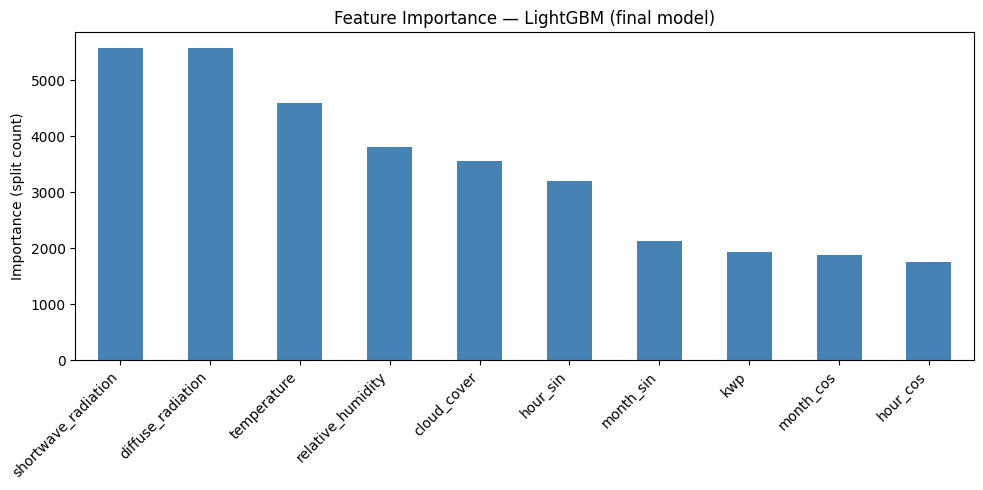

In [35]:
lgbm_final.fit(X_train, y_train)
y_pred_final = lgbm_final.predict(X_test)

feat_imp = (
    pd.Series(lgbm_final.feature_importances_, index=FEATURES)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Feature Importance — LightGBM (final model)')
ax.set_ylabel('Importance (split count)')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`shortwave_radiation` and `diffuse_radiation` rank highest, followed by `temperature`.
`relative_humidity` ranks lower here (4th) than its correlation with the target would
suggest (2nd strongest in section 5.2), likely because split count reflects how often
a feature is used, not how strongly it relates to the target, and part of its
information may already be captured by higher-ranked features. `cloud_cover` sits at a
similar level to `relative_humidity`. Among the time encodings, `hour_sin` is used
more than `month_sin`, `month_cos`, or `hour_cos`.

`kwp` ranks near the bottom, close to the least-used cyclic features. This does not
mean it carries little information: since `capacity_factor` is itself defined as
`solar_generation / kwp`, its role is less about adding a new signal at each split and
more about rescaling the relationship between weather and production so the model
generalizes across sites of different sizes.

### 7.11 Saving Model Artifacts


In [36]:
import joblib
import os

joblib.dump(lgbm_final, '../model/model_solar_prediction.pkl')

model_info = {
    'features':        FEATURES,
    'target':          TARGET,
    'model_name':      'LightGBM',
    'r2':              round(lgbm_cv_results['r2_mean'], 4),
    'r2_day':          round(lgbm_cv_results['r2_day_mean'], 4),
    'mae':             round(lgbm_cv_results['mae_mean'], 4),
    'mae_day':         round(lgbm_cv_results['mae_day_mean'], 4),
    'sites_count':     int(df_clean['site_key'].nunique()),
    'trained_from':    str(df_clean['timestamp'].min().date()),
    'trained_to':      str(df_clean['timestamp'].max().date()),
}

joblib.dump(model_info, 'model_info.pkl')

print('Saved: ../model/model_solar_prediction.pkl')
print('Saved: ../model/model_info.pkl')

Saved: ../model/model_solar_prediction.pkl
Saved: ../model/model_info.pkl


<a id="8"></a> 
## 8. Conclusion and Limitations

This notebook set out to predict hourly solar power generation for a university
campus from publicly available weather data, using a single model able to generalize
across sites of different sizes. The final model, a LightGBM regressor tuned with
Optuna, reaches R² = 0.8875 overall and R² = 0.8121 on daylight hours, with an MAE of
0.0647 on daylight hours, averaged over 5-fold time-series cross-validation.

Along the way, several findings shaped the final approach:

- A naive seasonal average and a Linear Regression already explained a substantial
  share of the variance (R² of 0.79 and 0.85 overall), showing that weather data
  carries real predictive signal even with the simplest models. This provided an
  early, encouraging signal that a machine learning approach was worth pursuing
  further.

- Random Forest and LightGBM both improved noticeably on the linear baseline,
  indicating that the relationship between weather and production is meaningfully
  non-linear.

- A neural network was also tried, mainly to check the approach thoroughly. It
  performed comparably to LightGBM but did not exceed it once training cost and the
  need for feature scaling were taken into account, so LightGBM was retained as the
  final model.

- Feature importance broadly matched the correlation analysis from section 5.2, with
  irradiance-related features dominating, though not perfectly: `relative_humidity`
  ranked lower in importance than its correlation with the target would suggest, a
  reminder that the two measures capture different things.

Several limitations are worth keeping in mind when interpreting these results:

- The model is trained on a single campus (Bundoora). Generalization to other
  locations, with different climates or panel configurations, has not been tested.

- Four sites were excluded due to implausible capacity factor values, most likely
  caused by incorrect `kWp` metadata rather than a genuine difference in performance.
  These sites could be revisited if corrected metadata becomes available.

- A residual share of daytime records still has missing production values, left
  unfilled by design rather than estimated, which slightly reduces the size of the
  training set.
  
- Daylight-hour metrics remain meaningfully lower than overall metrics, showing that
  the hours that matter most for forecasting are also the hardest to predict.

Because Open-Meteo's Forecast API exposes the same variables as its Historical API
(section 3.1), this model is not limited to explaining past production: it can also
be used to forecast future generation, by feeding it weather forecasts instead of
historical records.